### Import Required Libraries 

In [4]:
#import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# imprt warning for cleaner output
import warnings
warnings. filterwarnings('ignore')


### Load dataset 

In [5]:
# Load dataset
df = pd.read_csv("bank-marketing.csv")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


### Data Visualization 

In [14]:
df.head() # view dataset

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


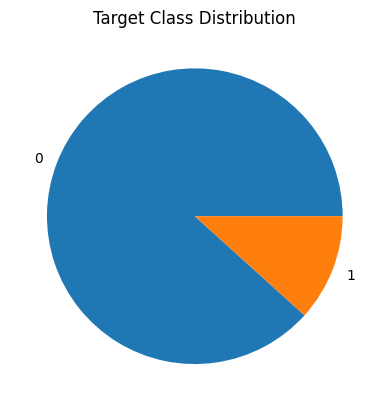

In [13]:
import matplotlib.pyplot as plt  # Import plotting library

counts = df['Class'].value_counts()  # Count class values

plt.pie(counts.values, labels=counts.index.astype(str))  # Create pie chart
plt.title("Target Class Distribution")  # Add title
plt.show()  # Display pie chart

### Data Prepocessing 

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Encode target and categorical features
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])   # yes=1, no=0

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


### Split Feature and Target



In [7]:
# Separate features and target
X = df.drop('Class', axis=1) # Feature variables
y = df['Class'] # Target variable


### Data Splitting

In [8]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the dataset intro training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling 

In [9]:
# Initialize the StandardScaler
scaler = StandardScaler()
# Scale training data 
X_train_scaled = scaler.fit_transform(X_train)
# Scale testing data
X_test_scaled = scaler.transform(X_test)


In [10]:
X_train_scaled # view scaled X_train 

array([[ 0.00651495, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.75993671,  1.42325035, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.10069267, -1.32605277, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       ...,
       [-0.65272909,  1.42325035, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.74690681,  0.20133786, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.27601821, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ]], shape=(36168, 16))

In [11]:
X_test_scaled # view scaled X_test

array([[-0.08766277, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.57158127,  0.81229411,  1.36974507, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-1.50032857,  1.11777223,  1.36974507, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       ...,
       [ 1.04246987, -1.32605277, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.08766277, -1.32605277, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.37019593,  1.42325035, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ]], shape=(9043, 16))

### Model Selection: SVM - SVC

In [126]:
# Import Support Vector Classifier (SVC) for classification
from sklearn.svm import SVC 
# Create SVM model
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train) #compute the optimal hyperplane
y_pred = svm_model.predict(X_test_scaled) #classifies test data point 

### Model Evaluation 

In [127]:
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report # Import evaluation metrics
accuracy = accuracy_score(y_test, y_pred) # Calculate model accuracy
print("SVC Accuracy:", accuracy) # Print accuracy of the SVM model
print("\nClassification Report:\n", classification_report(y_test, y_pred)) # Display precision, recall, F1-score, and support

SVC Accuracy: 0.8963839433816212

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.67      0.28      0.40      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.63      0.67      9043
weighted avg       0.88      0.90      0.88      9043



### Final Visualization 

In [123]:
# Calculate False Positive Rate and True Positive Rate for ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba)  

# Calculate Area Under the Curve (AUC)
roc_auc_svm = auc(fpr_svm, tpr_svm)       

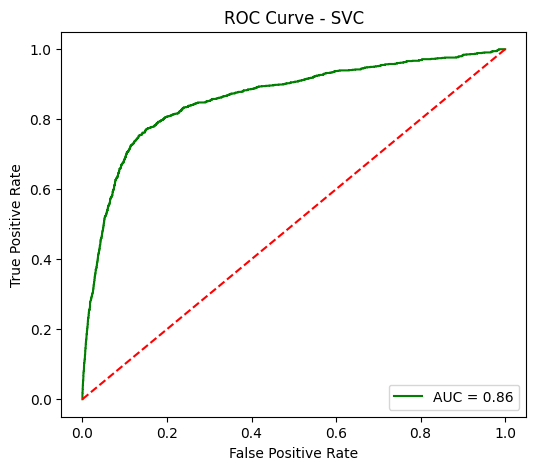

In [118]:

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, color='green', label=f'AUC = {roc_auc_svm:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('ROC Curve - SVC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()